# Week 1 — Logistic Regression and Gradient Descent

This notebook works through all six parts. We derive the losses and gradients,
implement gradient descent from scratch, and run the full sequence of
experiments on the synthetic 2D dataset and the breast-cancer dataset.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=6, suppress=True)
%matplotlib inline

## Derivations

Let $z = w^\top x + b$ and $p = \sigma(z) = 1/(1+e^{-z})$. Useful identity:
$\sigma'(z) = p(1-p)$.

### Cross-entropy

$$
L_{\mathrm{CE}} = -\tfrac{1}{N}\sum_i \big[y_i \log p_i + (1-y_i)\log(1-p_i)\big].
$$

Per sample, $\partial L/\partial z = p - y$ (the classic cancellation — the
$p(1-p)$ from $\sigma'$ cancels the $1/p$ and $1/(1-p)$ from $\log$). Then

$$
\nabla_w L_{\mathrm{CE}} = \tfrac{1}{N} X^\top (p - y),\qquad
\partial_b L_{\mathrm{CE}} = \tfrac{1}{N}\sum_i (p_i - y_i).
$$

### MSE (between sigmoid and label)

$$
L_{\mathrm{MSE}} = \tfrac{1}{N}\sum_i (p_i - y_i)^2.
$$

Here $\partial L/\partial z = 2(p-y)\,p(1-p)$. So

$$
\nabla_w L_{\mathrm{MSE}} = \tfrac{1}{N} X^\top\!\big[2(p-y)\,p(1-p)\big],
\qquad
\partial_b L_{\mathrm{MSE}} = \tfrac{1}{N}\sum_i 2(p_i-y_i)\,p_i(1-p_i).
$$

**Where the extra factor vanishes.** The MSE gradient carries an extra
$p(1-p)$ that CE does not. That factor goes to $0$ whenever $p \to 0$ or
$p \to 1$, i.e. whenever the model is very confident — correct *or*
incorrect. CE has no such factor, so confident-but-wrong points still
produce a large gradient.


## Core implementations

In [ ]:
def sigmoid(z):
    # numerically stable
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def ce_loss(w, b, X, y):
    z = X @ w + b
    # log(1+exp(z)) - y*z   is the stable form of -[y log p + (1-y) log(1-p)]
    return float(np.mean(np.logaddexp(0.0, z) - y * z))

def ce_grad(w, b, X, y):
    p = sigmoid(X @ w + b)
    err = p - y
    return X.T @ err / X.shape[0], float(err.mean())

def mse_loss(w, b, X, y):
    p = sigmoid(X @ w + b)
    return float(np.mean((p - y) ** 2))

def mse_grad(w, b, X, y):
    p = sigmoid(X @ w + b)
    factor = 2.0 * (p - y) * p * (1.0 - p)
    return X.T @ factor / X.shape[0], float(factor.mean())

def gradient_descent(X, y, loss_fn, grad_fn, w0, b0, lr, n_iter):
    w = np.array(w0, dtype=float).copy()
    b = float(b0)
    ws, bs = [w.copy()], [b]
    losses = [loss_fn(w, b, X, y)]
    gnorms = []
    for _ in range(n_iter):
        gw, gb = grad_fn(w, b, X, y)
        gnorms.append(float(np.sqrt(np.sum(gw*gw) + gb*gb)))
        w = w - lr * gw
        b = b - lr * gb
        ws.append(w.copy()); bs.append(b)
        losses.append(loss_fn(w, b, X, y))
    gw, gb = grad_fn(w, b, X, y)
    gnorms.append(float(np.sqrt(np.sum(gw*gw) + gb*gb)))
    return w, b, {
        "w": np.array(ws), "b": np.array(bs),
        "loss": np.array(losses), "grad_norm": np.array(gnorms),
    }

def accuracy(w, b, X, y):
    return float(np.mean((sigmoid(X @ w + b) >= 0.5).astype(int) == y))

## Data (Parts 1–5)

In [ ]:
X, y = make_classification(
    n_samples=400, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.3, random_state=0,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)
print(f"train: {X_tr.shape}, test: {X_te.shape}")

train: (300, 2), test: (100, 2)


## Part 1 — Cross-entropy, small initialization

In [ ]:
w0_small = np.array([0.01, -0.01])
b0 = 0.0
w1, b1, hist1 = gradient_descent(X_tr, y_tr, ce_loss, ce_grad,
                                  w0_small, b0, lr=0.1, n_iter=2000)
print(f"final w          = {w1}")
print(f"final b          = {b1:.6f}")
print(f"train accuracy   = {accuracy(w1, b1, X_tr, y_tr):.4f}")
print(f"test  accuracy   = {accuracy(w1, b1, X_te, y_te):.4f}")
print(f"loss @ iter 0    = {hist1['loss'][0]:.6f}")
print(f"loss @ iter 100  = {hist1['loss'][100]:.6f}")
print(f"loss @ iter 2000 = {hist1['loss'][2000]:.6f}")

final w          = [-1.216318  2.929677]
final b          = 2.370431
train accuracy   = 0.9300
test  accuracy   = 0.8900
loss @ iter 0    = 0.699814
loss @ iter 100  = 0.262572
loss @ iter 2000 = 0.197832


**Recorded values (Part 1).**
- Final weights: $w \approx (-1.216,\ 2.930)$, bias $b \approx 2.370$
- Train accuracy $= 0.9300$, test accuracy $= 0.8900$
- Loss at iter 0 / 100 / 2000: $0.6998\ /\ 0.2626\ /\ 0.1978$


## Part 2 — MSE, and both losses from $(4, -4)$

In [ ]:
# MSE with the small init
_, _, hist_mse_s = gradient_descent(X_tr, y_tr, mse_loss, mse_grad,
                                    w0_small, b0, lr=0.1, n_iter=2000)

# Both losses with big init
w0_big = np.array([4.0, -4.0])
_, _, hist_ce_b  = gradient_descent(X_tr, y_tr, ce_loss,  ce_grad,
                                    w0_big, b0, lr=0.1, n_iter=2000)
_, _, hist_mse_b = gradient_descent(X_tr, y_tr, mse_loss, mse_grad,
                                    w0_big, b0, lr=0.1, n_iter=2000)

print(f"MSE grad norm @ iter 0   (from (4,-4)) = {hist_mse_b['grad_norm'][0]:.6e}")
print(f"MSE grad norm @ iter 100 (from (4,-4)) = {hist_mse_b['grad_norm'][100]:.6e}")

MSE grad norm @ iter 0   (from (4,-4)) = 8.894045e-02
MSE grad norm @ iter 100 (from (4,-4)) = 1.028034e-01


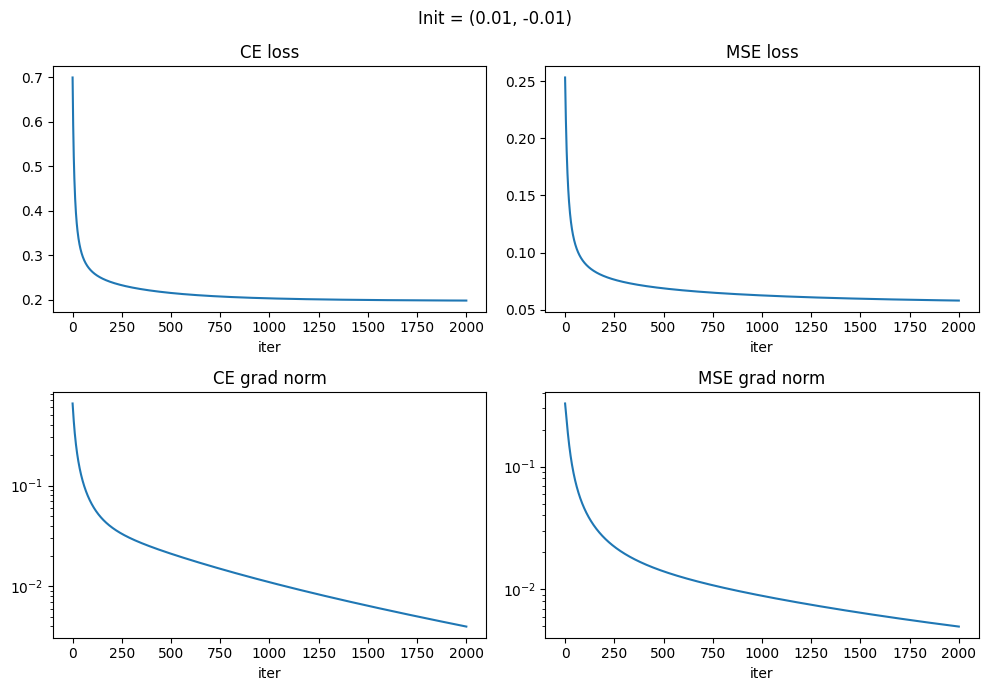

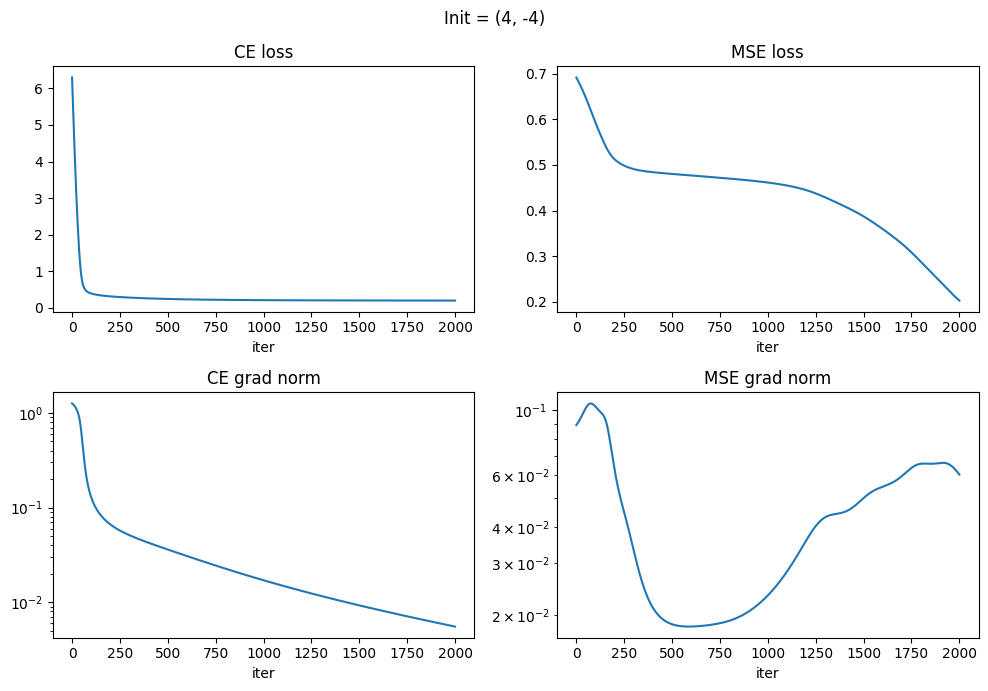

In [ ]:
def plot_part2(hist_ce, hist_mse, title):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes[0,0].plot(hist_ce['loss']);  axes[0,0].set_title('CE loss');  axes[0,0].set_xlabel('iter')
    axes[0,1].plot(hist_mse['loss']); axes[0,1].set_title('MSE loss'); axes[0,1].set_xlabel('iter')
    axes[1,0].plot(hist_ce['grad_norm']);  axes[1,0].set_title('CE grad norm');
    axes[1,0].set_yscale('log'); axes[1,0].set_xlabel('iter')
    axes[1,1].plot(hist_mse['grad_norm']); axes[1,1].set_title('MSE grad norm');
    axes[1,1].set_yscale('log'); axes[1,1].set_xlabel('iter')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_part2(hist1,     hist_mse_s, 'Init = (0.01, -0.01)')
plot_part2(hist_ce_b, hist_mse_b, 'Init = (4, -4)')

**Recorded values (Part 2).**
- MSE gradient norm at iter 0 from $(4,-4)$: $\approx 8.89\times 10^{-2}$
- MSE gradient norm at iter 100 from $(4,-4)$: $\approx 1.03\times 10^{-1}$

**What you can see in the plots.** With the big init, CE has a huge starting
gradient and loss and drives them down quickly. MSE starts with a tiny
gradient and barely moves for hundreds of iterations — this is the $p(1-p)$
factor killing the signal when the model is confidently wrong (a prediction
near 0 or 1 on examples of the other class). This is exactly why logistic
regression is trained with cross-entropy and not MSE-on-sigmoid.


## Part 3 — Feature scaling and learning rate

In [ ]:
X_tr_rs = X_tr.copy(); X_tr_rs[:, 0] *= 100.0

std_before = X_tr[:, 0].std() / X_tr[:, 1].std()
std_after  = X_tr_rs[:, 0].std() / X_tr_rs[:, 1].std()
print(f"std(feature0)/std(feature1) before = {std_before:.4f}")
print(f"std(feature0)/std(feature1) after  = {std_after:.4f}")
print(f"ratio of ratios                    = {std_after/std_before:.2f}")

std(feature0)/std(feature1) before = 0.4858
std(feature0)/std(feature1) after  = 48.5823
ratio of ratios                    = 100.00


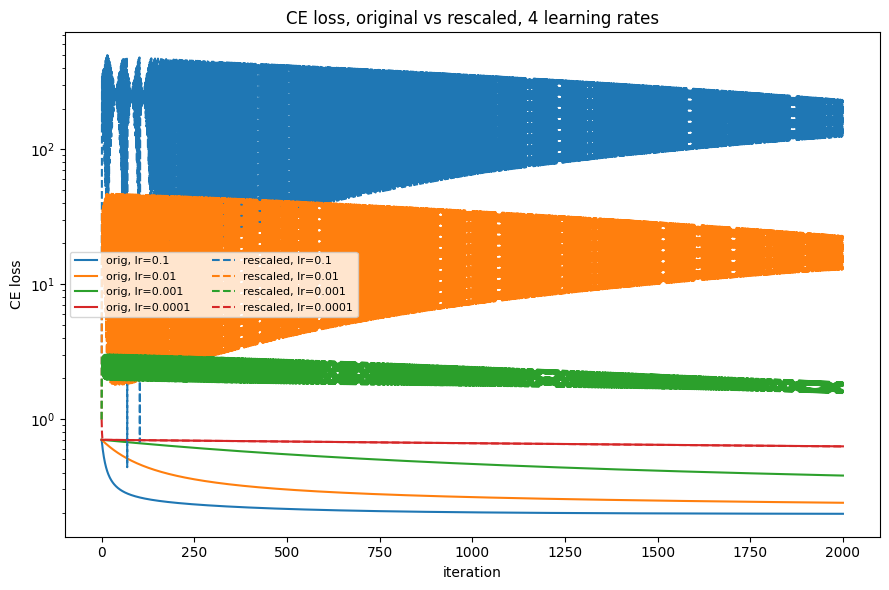


Final losses on rescaled data:
  lr=0.1:  final loss = 231.7561
  lr=0.01:  final loss = 12.8057
  lr=0.001:  final loss = 1.5533
  lr=0.0001:  final loss = 0.6247


In [ ]:
lrs = [0.1, 0.01, 0.001, 0.0001]
part3_hist = {}
for tag, data in [('orig', X_tr), ('rescaled', X_tr_rs)]:
    for lr in lrs:
        _, _, h = gradient_descent(data, y_tr, ce_loss, ce_grad,
                                   w0_small, 0.0, lr=lr, n_iter=2000)
        part3_hist[(tag, lr)] = h

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0.1:'C0', 0.01:'C1', 0.001:'C2', 0.0001:'C3'}
styles = {'orig':'-', 'rescaled':'--'}
for (tag, lr), h in part3_hist.items():
    ax.plot(h['loss'], color=colors[lr], linestyle=styles[tag],
            label=f'{tag}, lr={lr}')
ax.set_xlabel('iteration'); ax.set_ylabel('CE loss')
ax.set_yscale('log')
ax.legend(ncol=2, fontsize=8)
ax.set_title('CE loss, original vs rescaled, 4 learning rates')
plt.tight_layout(); plt.show()

print('\nFinal losses on rescaled data:')
for lr in lrs:
    final = part3_hist[('rescaled', lr)]['loss'][-1]
    print(f'  lr={lr}:  final loss = {final:.4f}')

**Recorded values (Part 3).**
- Std ratio $\text{std}(x_0)/\text{std}(x_1)$ before: $\approx 0.486$, after: $\approx 48.58$ (a factor of $100\times$, as expected).
- Largest learning rate that converges on the rescaled data: $\mathbf{10^{-4}}$. All larger rates diverge (the final loss is larger than the initial one, and growing).

**Why.** After we scale $x_0$ by 100, its gradient component is scaled by 100
as well. Stability of gradient descent is roughly governed by the largest
curvature, which on rescaled data is about $100^2 = 10{,}000$ times bigger.
We need to shrink the learning rate by a comparable factor — which is
exactly the jump from $\sim 10^{-1}$ (fine on original) to $\sim 10^{-4}$
(the first that works on rescaled).


## Part 4 — Loss landscape with four trajectories

We fix $b$ at its Part 1 value, plot CE loss as a function of $(w_0, w_1)$,
and overlay four gradient-descent paths chosen to show the main regimes.


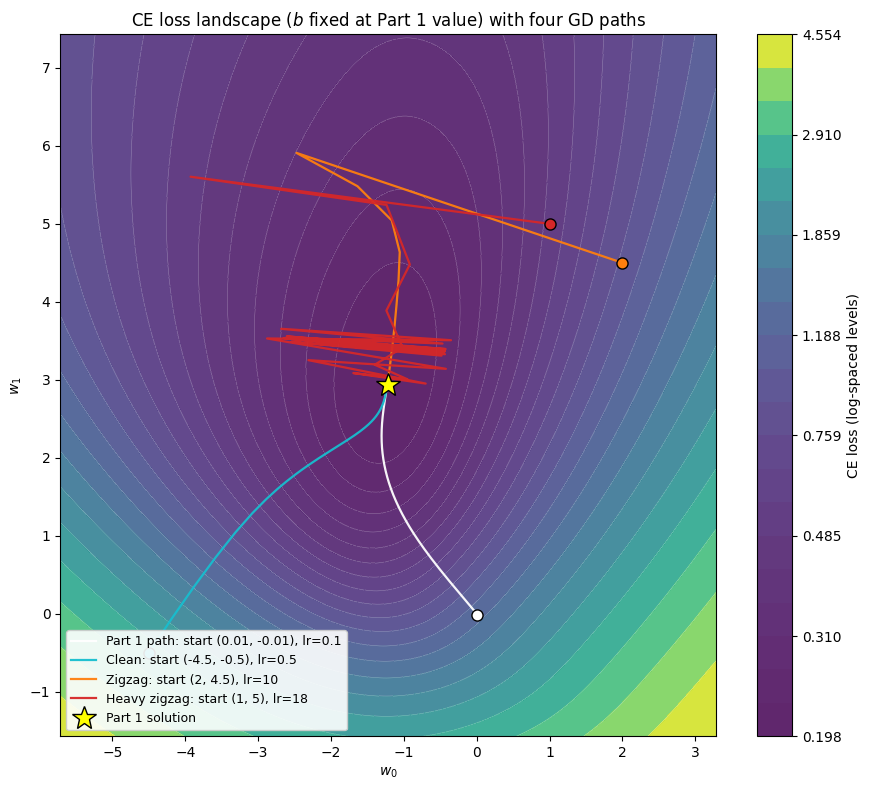

In [ ]:
# ============================================================
# Part 4 — CE loss landscape (b fixed) with four GD paths
# ============================================================
# Fix b at the Part 1 value and view CE(w_0, w_1) as a surface.
# Overlay the Part 1 path plus three more paths from different
# starting points and learning rates to expose the geometry.

b_fixed = b1
w_opt = w1

# Rectangle around the Part 1 solution
pad = 4.5
w0_grid = np.linspace(w_opt[0] - pad, w_opt[0] + pad, 200)
w1_grid = np.linspace(w_opt[1] - pad, w_opt[1] + pad, 200)
W0, W1 = np.meshgrid(w0_grid, w1_grid)

# Vectorized CE loss on the grid (stable form: softplus(z) - y*z)
Wflat = np.stack([W0.ravel(), W1.ravel()], axis=1)          # (G, 2)
Z = Wflat @ X_tr.T + b_fixed                                 # (G, N)
L = np.mean(np.logaddexp(0.0, Z) - y_tr * Z, axis=1).reshape(W0.shape)

# Gradient that only updates w (b is frozen at b_fixed)
def ce_grad_w_only(w, b, X, y):
    gw, _ = ce_grad(w, b, X, y)
    return gw, 0.0

# Four trajectories: the Part 1 path plus three chosen to expose
# the main regimes (clean convergence / mild zigzag / heavy zigzag).
traj_specs = [
    ("Part 1 path: start (0.01, -0.01), lr=0.1",  w0_small,                0.1,  2000),
    ("Clean: start (-4.5, -0.5), lr=0.5",          np.array([-4.5, -0.5]), 0.5,   400),
    ("Zigzag: start (2, 4.5), lr=10",              np.array([ 2.0,  4.5]), 10.0,  100),
    ("Heavy zigzag: start (1, 5), lr=18",          np.array([ 1.0,  5.0]), 18.0,   80),
]
trajs = []
for label, w0, lr, n in traj_specs:
    _, _, h = gradient_descent(X_tr, y_tr, ce_loss, ce_grad_w_only,
                               w0, b_fixed, lr=lr, n_iter=n)
    trajs.append((label, h['w']))

fig, ax = plt.subplots(figsize=(9, 8))
levels = np.logspace(np.log10(max(L.min(), 1e-3)), np.log10(L.max()), 22)
cs = ax.contourf(W0, W1, L, levels=levels, cmap='viridis', alpha=0.85)
ax.contour(W0, W1, L, levels=levels, colors='white', linewidths=0.4, alpha=0.5)
plt.colorbar(cs, ax=ax, label='CE loss (log-spaced levels)')

path_colors = ['white', 'tab:cyan', 'tab:orange', 'tab:red']
for (label, W), c in zip(trajs, path_colors):
    ax.plot(W[:, 0], W[:, 1], '-', color=c, lw=1.6, label=label, alpha=0.95)
    ax.plot(W[0, 0], W[0, 1], 'o', color=c, mec='black', ms=8)

ax.plot(w_opt[0], w_opt[1], '*', color='yellow', mec='black', ms=18,
        label='Part 1 solution')
ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_title(r'CE loss landscape ($b$ fixed at Part 1 value) with four GD paths')
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

**The loss landscape is anisotropic** ( we move at different speeds in different directions in parameter space). The contours are elliptical rather than circular. Around the minimum, the Hessian eigenvalues are roughly $0.143$ and $0.040$, giving a condition number of about $3.6$.


**The steep direction is mostly along $w_0$.** The largest-eigenvalue direction is approximately $(-0.99, 0.16)$, so gradient descent is most sensitive to learning rate changes along this axis.


**The shallow direction is roughly along $w_1$.** Progress along this direction is slower, which is why trajectories can reach the valley quickly but then move slowly toward the optimum.


**Large learning rates cause zigzagging.** The orange and red trajectories overshoot across the steep direction, bouncing from side to side while only slowly drifting along the shallow direction.


**Smaller learning rates produce smoother convergence.** The white and cyan paths first move quickly into the valley, then slide along the shallow direction toward the minimum.


**Connection to Part 3.** This is the same ill-conditioning mechanism as before, but milder: here the anisotropy is only about $3.6\times$, whereas feature rescaling in Part 3 created a much more elongated valley and required a much smaller stable learning rate.



## Part 5 — One-class training

In [ ]:
mask = (y_tr == 1)
X_one = X_tr[mask]
y_one = y_tr[mask]
print(f'Kept {len(X_one)} samples (all label 1)')

w5, b5, hist5 = gradient_descent(X_one, y_one, ce_loss, ce_grad,
                                 np.zeros(2), 0.0, lr=0.05, n_iter=5000)
wnorm = np.linalg.norm(hist5['w'], axis=1)

print(f'||w|| @ iter  100 = {wnorm[100]:.4f}')
print(f'||w|| @ iter 1000 = {wnorm[1000]:.4f}')
print(f'||w|| @ iter 5000 = {wnorm[5000]:.4f}')

Kept 148 samples (all label 1)
||w|| @ iter  100 = 1.1388
||w|| @ iter 1000 = 2.1058
||w|| @ iter 5000 = 2.7845


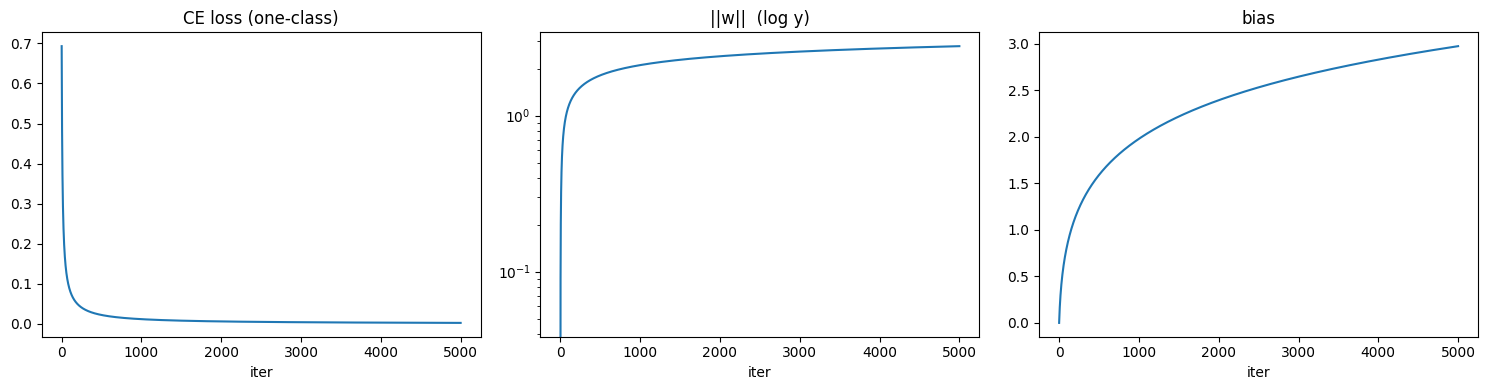

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist5['loss'])
axes[0].set_title('CE loss (one-class)'); axes[0].set_xlabel('iter')

axes[1].plot(wnorm)
axes[1].set_yscale('log')
axes[1].set_title('||w||  (log y)'); axes[1].set_xlabel('iter')

axes[2].plot(hist5['b'])
axes[2].set_title('bias'); axes[2].set_xlabel('iter')
plt.tight_layout(); plt.show()

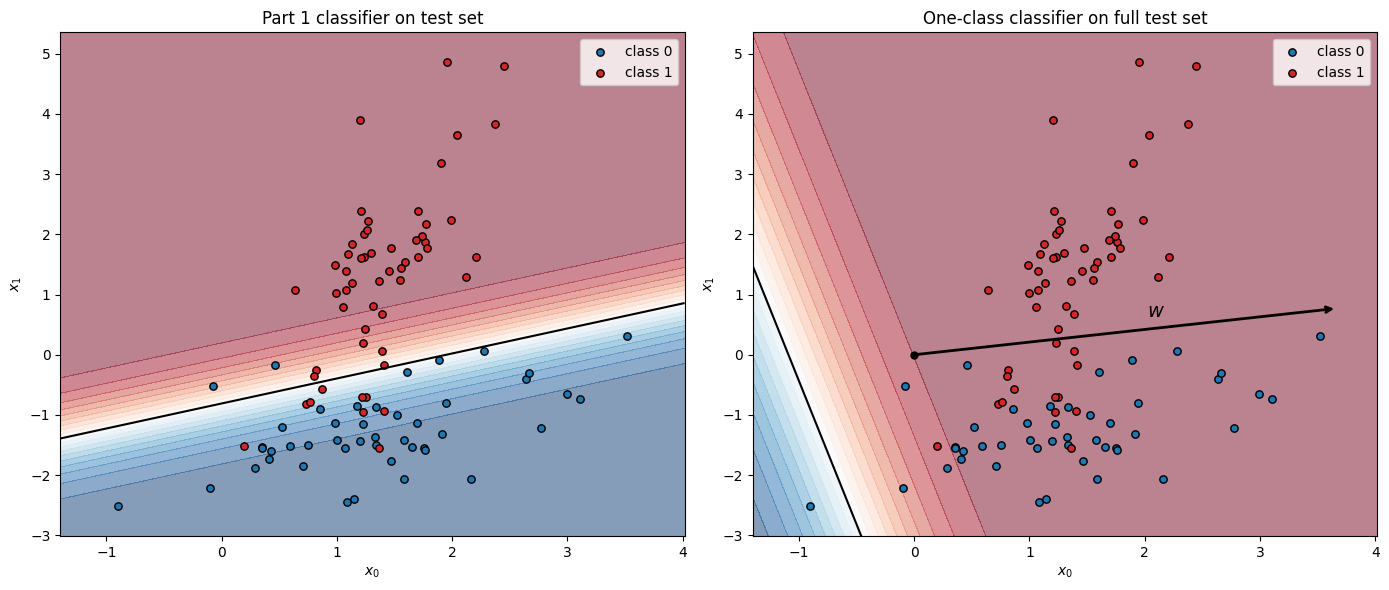

In [ ]:
# Side-by-side: Part 1 classifier on full data vs one-class classifier on full test data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def draw_decision_bg(ax, w, b, X_plot, y_plot, title):
    x0 = np.linspace(X_plot[:,0].min()-0.5, X_plot[:,0].max()+0.5, 200)
    x1 = np.linspace(X_plot[:,1].min()-0.5, X_plot[:,1].max()+0.5, 200)
    XX, YY = np.meshgrid(x0, x1)
    G = np.stack([XX.ravel(), YY.ravel()], axis=1)
    P = sigmoid(G @ w + b).reshape(XX.shape)
    ax.contourf(XX, YY, P, levels=20, cmap='RdBu_r', alpha=0.5)
    ax.contour(XX, YY, P, levels=[0.5], colors='k', linewidths=1.5)
    for c, col, lab in [(0, 'tab:blue', 'class 0'), (1, 'tab:red', 'class 1')]:
        ax.scatter(X_plot[y_plot==c, 0], X_plot[y_plot==c, 1],
                   c=col, edgecolor='k', s=28, label=lab)
    ax.set_title(title); ax.set_xlabel('$x_0$'); ax.set_ylabel('$x_1$')
    ax.legend(loc='best')

draw_decision_bg(axes[0], w1, b1, X_te, y_te, 'Part 1 classifier on test set')

draw_decision_bg(axes[1], w5, b5, X_te, y_te,
                 'One-class classifier on full test set')
# draw weight vector as arrow from origin, scaled to be visible
scale = 0.7 * max(np.abs(axes[1].get_xlim()).max(), np.abs(axes[1].get_ylim()).max()) / max(np.linalg.norm(w5), 1e-9)
axes[1].annotate('', xy=(w5[0]*scale, w5[1]*scale), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=2))
axes[1].plot(0, 0, 'ko', ms=5)
axes[1].text(w5[0]*scale*0.55, w5[1]*scale*0.55 + 0.2, '$w$', fontsize=14)
plt.tight_layout(); plt.show()

**Recorded values (Part 5).**
- $\|w\|$ at iter $100 / 1000 / 5000$: $\approx 1.14\ /\ 2.11\ /\ 2.78$.

**Additional questions.**

1. **Cross-entropy loss.** $L = -\tfrac{1}{N}\sum_i [y_i \log p_i + (1-y_i)\log(1-p_i)]$.

2. **With all $y_i = 1$**, this collapses to $L = -\tfrac{1}{N}\sum_i \log p_i$.

3. **Minimizer.** Each term $-\log p_i$ is minimized by $p_i = 1$, which
   requires the pre-sigmoid $z_i = w^\top x_i + b \to +\infty$.

4. **Reachable with finite parameters?** No. $\sigma(z) = 1$ exactly only in
   the limit $z \to \infty$. So no finite $(w, b)$ achieves the infimum; the
   parameters have to grow without bound (either $\|w\|\to\infty$, or
   $b\to\infty$, or both, along a direction where $w^\top x_i + b$ is
   positive for every training point).

5. **Does the plot match?** Yes. $\|w\|$ and $b$ both grow monotonically and
   do not settle — loss is still decreasing at iter 5000. This is the
   infinite-weight pathology in action, at finite-step speed.

6. **Predictions on the full test set.** Because both $w$ and $b$ grow, the
   argument $w^\top x + b$ is large and positive for essentially all points,
   so the model predicts class 1 everywhere — including on the class-0
   cluster, and in particular far from training data. It has learned "say
   1" rather than a useful boundary.

7. **One-sentence summary.** Trained on one class, logistic regression has
   no finite optimum because CE is monotonic in confidence — this is the
   same failure mode as the classical result that logistic regression on
   linearly separable data has no finite maximum-likelihood estimate and
   the parameters diverge along the max-margin direction.

8. **(Bonus) A loss that fixes this.** Add any strictly convex penalty on
   $(w, b)$, e.g. $\ell_2$ regularization: $L_{\text{reg}} = L_{\mathrm{CE}}
   + \tfrac{\lambda}{2}\|w\|^2$. It works because the penalty is coercive —
   the total loss now goes to $+\infty$ as $\|w\|\to\infty$, so the minimum
   is attained at finite weights. (Equivalently, a Gaussian prior on $w$ in
   the MAP view.) An alternative is to require at least one example from
   each class.


## Part 6 — Breast cancer: standardized vs not

In [ ]:
bc = load_breast_cancer()
Xb, yb = bc.data, bc.target
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25, random_state=0)

mu = Xb_tr.mean(axis=0)
sd = Xb_tr.std(axis=0)
Xb_tr_s = (Xb_tr - mu) / sd
Xb_te_s = (Xb_te - mu) / sd

# feature scale spread
feat_stds = Xb_tr.std(axis=0)
print(f'Feature std: min={feat_stds.min():.4f}  max={feat_stds.max():.4f}  '
      f'ratio={feat_stds.max()/feat_stds.min():.1f}')

Feature std: min=0.0026  max=585.6644  ratio=222922.1


In [ ]:
d = Xb_tr.shape[1]
# standardized: lr=0.1 is fine
w_s, b_s, h_s = gradient_descent(Xb_tr_s, yb_tr, ce_loss, ce_grad,
                                 np.zeros(d), 0.0, lr=0.1, n_iter=2000)

# unstandardized: need tiny lr because some features have very large std
w_n, b_n, h_n = gradient_descent(Xb_tr, yb_tr, ce_loss, ce_grad,
                                 np.zeros(d), 0.0, lr=1e-6, n_iter=2000)

print(f'Standardized   : train acc = {accuracy(w_s, b_s, Xb_tr_s, yb_tr):.4f}, '
      f'test acc = {accuracy(w_s, b_s, Xb_te_s, yb_te):.4f}, '
      f'final train loss = {h_s["loss"][-1]:.4f}')
print(f'Unstandardized : train acc = {accuracy(w_n, b_n, Xb_tr, yb_tr):.4f}, '
      f'test acc = {accuracy(w_n, b_n, Xb_te, yb_te):.4f}, '
      f'final train loss = {h_n["loss"][-1]:.4f}')

# do they ever reach the same loss?
target = h_s['loss'][-1]
std_iters_to_target = int(np.argmax(h_s['loss'] <= target) if np.any(h_s['loss'] <= target) else -1)
unstd_ever = bool(np.any(h_n['loss'] <= target))
print(f'\nStandardized reaches loss {target:.4f} by iter {std_iters_to_target}')
print(f'Unstandardized reaches that loss within 2000 iters? {unstd_ever}')

Standardized   : train acc = 0.9906, test acc = 0.9720, final train loss = 0.0532
Unstandardized : train acc = 0.9085, test acc = 0.8951, final train loss = 0.3743

Standardized reaches loss 0.0532 by iter 2000
Unstandardized reaches that loss within 2000 iters? False


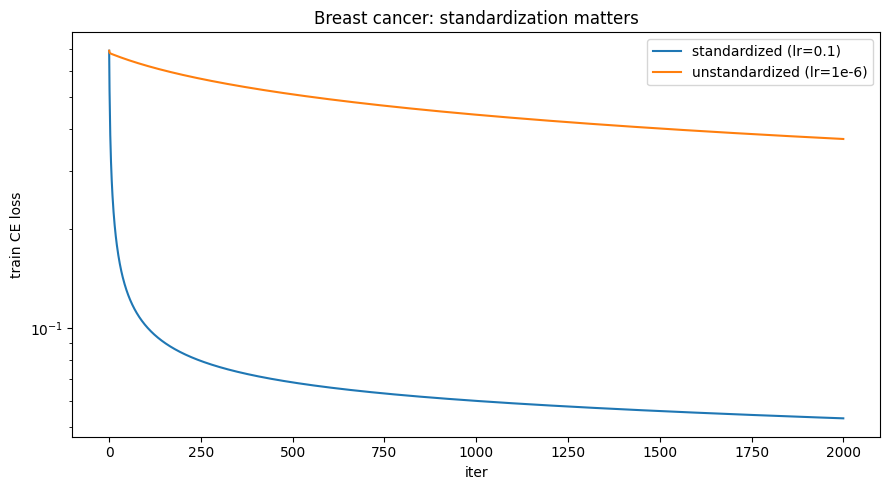

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_s['loss'], label='standardized (lr=0.1)')
ax.plot(h_n['loss'], label='unstandardized (lr=1e-6)')
ax.set_xlabel('iter'); ax.set_ylabel('train CE loss')
ax.set_yscale('log')
ax.legend()
ax.set_title('Breast cancer: standardization matters')
plt.tight_layout(); plt.show()

**Results and connection to Part 3.** On the raw breast-cancer data,
some features have standard deviations in the hundreds (area, perimeter)
while others are below $0.1$ — a spread of roughly three orders of
magnitude. That is a much more extreme version of the $100\times$
rescaling we did by hand in Part 3, and the consequences are the same:

- At lr $= 0.1$ (which works beautifully on the standardized data), training
  on raw features diverges immediately.
- Even at lr $= 10^{-6}$, which is about the largest that keeps things
  stable, the unstandardized run never reaches the final loss the
  standardized run reaches in 2000 iterations.

The standardized run converges smoothly and generalizes (test accuracy
$\approx 0.97$). The unstandardized run is stuck on the shallow features
because the learning rate has to be set by the *steepest* feature, not the
feature that carries information. This is exactly the Part 3 picture with
30 features instead of 2: mismatched feature scales produce an
ill-conditioned landscape, and gradient descent pays for it.
